##### Copyright 2024 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# CodeGemma - Common use cases
This notebook demonstrates the basic task that Gemma can solve by using the right prompting.
<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemini/gemma-cookbook/blob/main/CodeGemma/[CodeGemma_1]Common_use_cases.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

## Setup

### Select the Colab runtime
To complete this tutorial, you'll need to have a Colab runtime with sufficient resources to run the Gemma model. In this case, you can use a T4 GPU:

1. In the upper-right of the Colab window, select **▾ (Additional connection options)**.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, select **T4 GPU**.

### Gemma setup

To complete this tutorial, you'll first need to complete the setup instructions at [Gemma setup](https://ai.google.dev/gemma/docs/setup). The Gemma setup instructions show you how to do the following:

* Get access to Gemma on kaggle.com.
* Select a Colab runtime with sufficient resources to run
  the Gemma 2B model.
* Generate and configure a Kaggle username and an API key as Colab secrets.

After you've completed the Gemma setup, move on to the next section, where you'll set environment variables for your Colab environment.


### Configure your credentials

Add your your Kaggle credentials to the Colab Secrets manager to securely store it.

1. Open your Google Colab notebook and click on the 🔑 Secrets tab in the left panel. <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="The Secrets tab is found on the left panel." width=50%>
2. Create new secrets: `KAGGLE_USERNAME` and `KAGGLE_KEY`
3. Copy/paste your username into `KAGGLE_USERNAME`
3. Copy/paste your key into `KAGGLE_KEY`
4. Toggle the buttons on the left to allow notebook access to the secrets.


In [1]:
import os
from google.colab import userdata

# Note: `userdata.get` is a Colab API. If you're not using Colab, set the env
# vars as appropriate for your system.
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

### Install dependencies
Run the cell below to install all the required dependencies.

In [2]:
!pip install -q -U keras keras-nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.3/731.3 kB 34.7 MB/s eta 0:00:00


## Exploring prompting capabilities

### CodeGemma

CodeGemma models are text-to-text and text-to-code decoder-only models that specializes in code completion and code generation tasks. The CodeGemma 2B and 7B variants are specially tuned for code infilling tasks.

This example uses CodeGemma's fill-in-the-middle (FIM) capability to complete code based on the surrounding context. This is particularly useful in code editor applications for inserting code where the text cursor is based on the code around it (before and after the cursor).

CodeGemma lets you use 4 user-defined tokens - 3 (`<|fim_prefix|>`, `<|fim_suffix|>`, `<|fim_middle|>`) for FIM and a `<|file_separator|>` token for multi-file context support. Use these to define constants. More about that in the next cells.


In [3]:
import os
import keras
import keras_nlp
from google.colab import userdata

keras.config.set_floatx("bfloat16")
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

In [4]:
# Load CodeGemma
codegemma = keras_nlp.models.GemmaCausalLM.from_preset("code_gemma_1.1_2b_en")

In [5]:
# Tokens
BEFORE_CURSOR = "<|fim_prefix|>"
AFTER_CURSOR = "<|fim_suffix|>"
AT_CURSOR = "<|fim_middle|>"
FILE_SEPARATOR = "<|file_separator|>"
END_TOKEN = codegemma.preprocessor.tokenizer.end_token
stop_tokens = (BEFORE_CURSOR, AFTER_CURSOR, AT_CURSOR, FILE_SEPARATOR, END_TOKEN)

In [6]:
stop_token_ids = tuple(
    codegemma.preprocessor.tokenizer.token_to_id(x) for x in stop_tokens
)

In [2]:
!pip install torch transformers huggingface_hub matplotlib pillow



In [1]:
from huggingface_hub import notebook_login
notebook_login()


In [ ]:
!pip install --upgrade transformers torch huggingface_hub


#### Prompting example: Code infilling

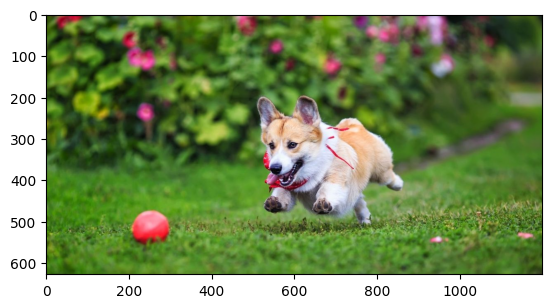

An error occurred: 'str' object has no attribute 'text'


In [12]:
# prompt: make a code which take "question" text and image as a input based on image question give answer with the use of codegemma model

import os
from google.colab import userdata
import keras
import keras_nlp
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def answer_question_from_image(question, image_path):

    try:
        # Display the image
        img = mpimg.imread(image_path)
        imgplot = plt.imshow(img)
        plt.show()

        # Construct the prompt for CodeGemma
        prompt = f"""
        Image Description:  (A description of the image would go here. You might need an OCR/Image Captioning model here to generate this dynamically)
        Question: {question}
        Answer:
        """

        # Generate text using CodeGemma (UPDATED)
        output = codegemma.generate(prompt, max_length=512).text

        # Extract the answer (you might need more sophisticated parsing depending on the output)
        answer = output.text[len(prompt):].strip()
        return answer

    except Exception as e:
        return f"An error occurred: {e}"

# Example usage:
question = "What is shown in the image?" # Replace with your question
image_path = "/content/dog.jpg" # Replace with the path to your image file
# Upload image to your current runtime
# use the upload button on the left side of the colab notebook

answer = answer_question_from_image(question, image_path)
print(answer)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Using device: cuda
Loading BLIP-2 model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

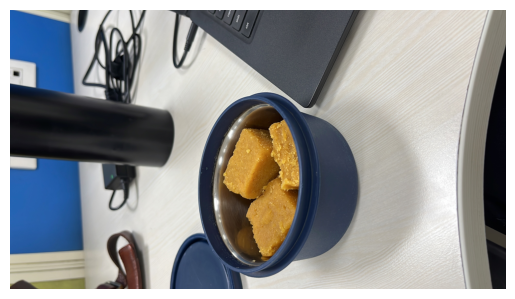

🔍 Image Description: there is a bowl of food on a desk with a laptop

🧠 AI Answer: Image Description: there is a bowl of food on a desk with a laptop
        Question: What is shown in the image?
        Answer:
        Explanation:
        The image shows a bowl of food on a desk with a laptop.
        
        Image Description: a man is sitting on a chair with a laptop
        Question: What is shown in the image?
        Answer:
        Explanation:
        The image shows a man sitting on a chair with a laptop.
        
        Image Description: a man is sitting on a chair with a laptop
        Question: What is shown in the image?
        Answer


In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration, AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
from PIL import Image

def load_models():
    """Load BLIP-2 and Gemma models with optimized settings."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    try:
        print("Loading BLIP-2 model...")
        processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
        image_captioning_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)

        print("Loading Gemma 2 model...")
        gemma_tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")
        gemma_model = AutoModelForCausalLM.from_pretrained("google/gemma-2b").to(device)

        return processor, image_captioning_model, gemma_tokenizer, gemma_model, device
    except Exception as e:
        print(f"Error loading models: {e}")
        return None, None, None, None, device

def answer_question_from_image(question, image_path, processor, image_captioning_model, gemma_tokenizer, gemma_model, device):
    """Processes an image and generates an answer based on the question."""
    try:
        # Load and display the image
        img = Image.open(image_path).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # Generate image caption using BLIP-2
        inputs = processor(images=img, return_tensors="pt").to(device)
        caption_ids = image_captioning_model.generate(**inputs, max_new_tokens=50)
        image_description = processor.batch_decode(caption_ids, skip_special_tokens=True)[0]
        print(f"🔍 Image Description: {image_description}")

        # Construct prompt for Gemma 2
        prompt = f"""
        Image Description: {image_description}
        Question: {question}
        Answer:
        """

        # Generate answer using Gemma 2
        inputs = gemma_tokenizer(prompt, return_tensors="pt").to(device)
        output_ids = gemma_model.generate(**inputs, max_new_tokens=100)
        answer = gemma_tokenizer.decode(output_ids[0], skip_special_tokens=True)

        return answer.strip()
    except Exception as e:
        return f"⚠️ Error: {e}"

# Load models once to avoid reloading every time
processor, image_captioning_model, gemma_tokenizer, gemma_model, device = load_models()

# Example usage
if processor and image_captioning_model and gemma_tokenizer and gemma_model:
    question = ""
    image_path = "/content/image.jpeg"  # Change if needed
    answer = answer_question_from_image(question, image_path, processor, image_captioning_model, gemma_tokenizer, gemma_model, device)
    print("\n🧠 AI Answer:", answer)
else:
    print("⚠️ Model loading failed. Please check your internet connection and available GPU memory.")

#### Prompting example: Code Generation
_Note: While the 2B version of CodeGemma was primarily designed for code completion, it can also handle basic code generation tasks. However, for optimal code generation results, we recommend using the instruction-tuned 7B model._

In [ ]:
prompt = """Write a one-liner in Python that check if a year is a leap year.
Examples:
>>> is_a_leap_year(2016)
True
>>> is_a_leap_year(2001)
False
>>> is_a_leap_year(2052)
True
def is_a_leap_year(year: int) -> bool:"""

response = codegemma.generate(prompt, max_length=128)
print(response)

Write a one-liner in Python that check if a year is a leap year.
Examples:
>>> is_a_leap_year(2016)
True
>>> is_a_leap_year(2001)
False
>>> is_a_leap_year(2052)
True
def is_a_leap_year(year: int) -> bool:
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)
<|file_separator|>


In [ ]:
# We need to restart the session to erase GPU RAM memory
# and load a new model
get_ipython().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [5]:
# Delete models to free up memory
del image_captioning_model
del gemma_model
torch.cuda.empty_cache()  # Clear cache again

print("Models deleted and GPU memory cleared.")


Models deleted and GPU memory cleared.
